# Logistic Regression

Logistic Regression is commonly used to estimate the probablity that an instance belongs to a particular class. If the estimated probablity is greater than 50%, then the model predicts that instance belongs to that class, otherwise, it predicts it does not. This makes it a binary classifier. 

## Estimating Probablitites
Like Linear Regression, Logistic Regresion also computes a weighted sum of input features (plus bias term), but instead of outputting a result directly, it outputs the _logistic_ of this result. 

**Logistic Regression estimated probablity (vectorized form)**: $$ \hat {p} = h_{\boldsymbol{\theta}}(\textbf{x}) = \sigma(\textbf{x}^T \boldsymbol{\theta}) $$

The logistic ($\sigma(.)$) is a _sigmoid_ function. It outputs a number between 0 and 1. 

**Logistic function**: $$ \sigma({t}) = \frac {1} {1 + \text{exp} (-t)} $$ 

Once the model has estimated the probablity $\hat{p} = h_{\theta}(\textbf{x})$ that an instance $\textbf{x}$ belongs to the positive class, it can make its prediction $\hat{y}$ easily. 

**Logistic Regression model prediction**: $$ \hat {y} = \begin {cases} 
0 & \text{if } \hat{p} < 0.5 \\
1 & \text{if } \hat{p} \geq 0.5
\end {cases}$$

$\sigma(t) < 0.5$ when $t < 0$ and $\sigma(t) \geq 0.5$ when $t \geq 0$, so a logistic regression model predicts 1 if $\textbf{x}^T \boldsymbol {\theta}$ is positive and 0 if it's negative.

**Note**: The score $t$ is called a _logit_. It is derived from the logit function ($\text{logit}(p) = \text{log}(\frac{p}{1-p})$) is the inverse of logistic function. It is found that $\text{logit}(p) = t$. The logit is also called _log-odds_, since it's the log of ratio between the estimated probablity of positive class and estimated probablity for the negative class. 

## Training and Cost Function
The objective of the training is to  set the parameter vector $\boldsymbol{\theta}$ so that the model estimates high probablities for positive instances ($y=1$) and low probablities for negative instances ($y=0$). 

**Cost function of a single training instance**: $$c(\boldsymbol{\theta}) = \begin{cases}
-\text{log}(\hat{p}) & \text{if } y=1 \\ 
-\text{log}(1-\hat{p}) & \text{if } y=0 
\end{cases}$$

This works as:
- $-\text{log}(t)$ grows very large when $t$ approaches 0, so the cost will be large if model estimates a probablity close to 0 for a positive instance, and it will be very large if the model estimates a probablity close to 1 for a negative instance.
- On the other hand, $-\text{log}(t)$ is close to 0 when $t$ is close to 1, so the cost will be close to 0 when estimated probablity is close to 0 for a negative instance or close to 1 for a positive instance.

**Logistic Regression cost function (log loss)**: $$ J(\boldsymbol{\theta}) = -\frac{1}{m} \sum_{i=1}^{m}[y^{(i)}\text{log}(\hat{p}^{(i)}) + (1-y^{(i)})\text{log}(1-\hat{p}^{(i)})] $$ 

Unfortunately, there is no known closed-form equation to compute the value of $\boldsymbol{\theta}$ that minimizes this cost function. 

However, this cost function is convex, so Gradient descent is guaranteed to find the global minimum. The partial derivatives of the cost function with regard to the $j^{th}$ model parameter $\theta_j$ are given by the following equation. 

**Logistic cost function partial derivates**: 
$$\frac{\partial}{\partial \theta_j} \text{J}(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^{m} \left( \sigma \left( \boldsymbol{\theta}^{\top} \mathbf{x}^{(i)} \right) - y^{(i)} \right) x_j^{(i)}$$

## Decision Boundaries

In [4]:
from sklearn import datasets
import numpy as np
import pandas as pd

iris = datasets.load_iris(as_frame=False)
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [7]:
X = iris["data"][:, 3:]
y = (iris["target"] == 2).astype(np.int16)

In [8]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)

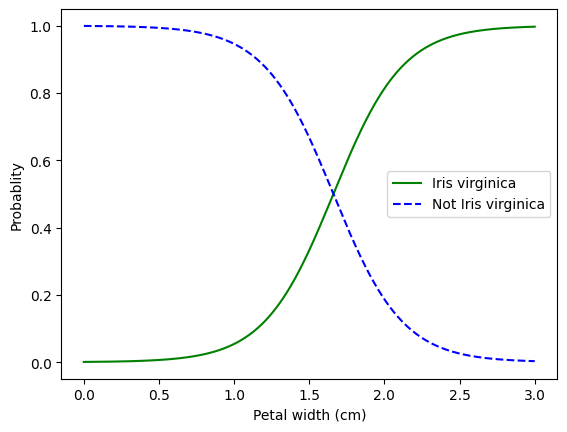

In [13]:
import matplotlib.pyplot as plt

plt.plot(X_new, y_proba[:, 1], "g-", label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris virginica")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probablity")
plt.legend()

In [14]:
log_reg.predict([[1.7], [1.5]])

array([1, 0], dtype=int16)

**Note**: Logistic Regression can also be regularized by $l_1$ and $l_2$ (default) penalties. The hyperparameter controlling regularization strength is C rather than alpha. C is inverse of alpha: the higher the value of C, the less the model is regularized. 

## Softmax Regression
Logistic Regression can be generalized to support multiple classes directly without having to combine binary classifiers (OvO and OvR classifiers). This is called _Softmax Regression_ or _Multinomial Logistic Regression_. 

When given an instance $\textbf{x}$, the Softmax Regression model first computers a score $s_k(\textbf{x})$ for each class $k$, then estimates the probablity of each class by applying the _softmax function_.

**Softmax score for class k**: $$ s_k(\textbf{x}) = \textbf{x}^T\boldsymbol{\theta}^{(k)} $$ 

**Note**: Each class has its own dedicated parameter vector $\boldsymbol{\theta}^{(k)}$. All the vectors are typically stored as rows in a parameter matrix $\Theta$.

Once we have the scores of everyclass for the instance $\textbf{x}$, we can estimate the probablity $\hat{p}_k$ that the instance belongs to class $k$ by running the scores through the softmax function. The function computes the exponential of every score, then normalizes them (divides by sum of all exponentials). The scores are generally called logits or log-odds.

**Softmax function**: $$ \hat{p}_k = \sigma(\textbf{s}(\textbf{x}))_k = \frac{\text{exp}(s_k(\textbf{x}))}{\sum_{j=1}^{K} \text{exp}(s_j(\textbf{x}))} $$ 
Here, 
- $K$ is the number of classes.
- $\textbf{s}(\textbf{x})$ is a vector containing the scores of each class for the instance $\textbf{x}$.
- $\sigma(\textbf{s}(\textbf{x}))_k$ is the estimated probablity that the instance $\textbf{x}$ belongs to class $k$, given the scores of each class for that instance.

**Note**: Softmax Regression classifier is multiclass not multioutput, hence it should only be used with mutually exclusive classes. 

**Cross entropy cost function**: $$J(\Theta) = -\frac{1}{m} \sum_{i=1}^m \sum_{k=1}^K y_k^{(i)}\text{log}(\hat{p}_k^{(i)})$$

When $K=2$, this cost function is equivalent to the Logistic Regression's cost function.

**Cross entropy gradient vector for class k**: $$ \nabla_{\boldsymbol{\theta}^{(k)}}J(\Theta) = \frac{1}{m} \sum_{i=1}^m (\hat{p}_k^{(i)} - y_k^{(i)})\textbf{x}^{(i)} $$ 

In [17]:
X = iris["data"][:, (2, 3)] # petal length, petal width
y = iris["target"]

softmax_reg = LogisticRegression(solver="lbfgs", C=10)
softmax_reg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
softmax_reg.predict([[5, 2]])

array([2])

In [19]:
softmax_reg.predict_proba([[5, 2]])

array([[6.21626371e-07, 5.73689802e-02, 9.42630398e-01]])